# LIBRARY

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


## import dataset

In [2]:
file_path = "../1.DATASET/df_CAL_vars.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_TBW_DELTA,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,BIA-BIA_FFMI_CAL,BIA-BIA_FFMI_DELTA,BIA-BIA_FMI_CAL,BIA-BIA_FMI_DELTA
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,0.00002,38.91765,0.00005,8.8953,6.22677,1864.996,13.816209,0.001491,3.061097,0.000333
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.00007,39.44961,0.00009,14.9739,12.39448,1873.312,12.823983,0.001417,1.211592,0.000128
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,NaN,57.14348,0.14708,16.0792,NaN,NaN,13.448050,0.644450,3.561984,0.136646


In [4]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

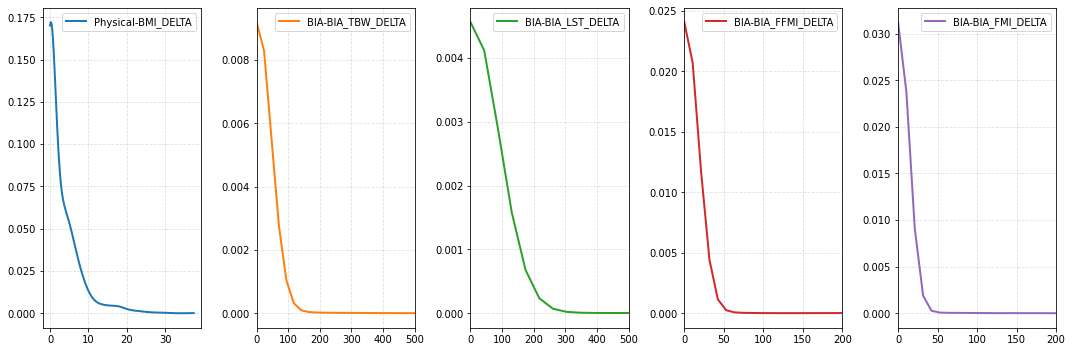

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 5, figsize=(15,5))

plots = [
    ("Physical-BMI_DELTA", "tab:blue"),
    ("BIA-BIA_TBW_DELTA", "tab:orange"),
    ("BIA-BIA_LST_DELTA", "tab:green"),
    ("BIA-BIA_FFMI_DELTA", "tab:red"),
    ('BIA-BIA_FMI_DELTA', "tab:purple")
]

for i, (col, color) in enumerate(plots):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)
    
    x_vals = np.linspace(data.min(), data.max(), 200)
    
    ax[i].plot(x_vals, kde(x_vals), linewidth=2, color=color, label=col)
    
    ax[i].legend()
    ax[i].grid(True, linestyle='--', alpha=0.4)

    # limiti asse x solo dove li avevi messi
    if col in ["BIA-BIA_TBW_DELTA", "BIA-BIA_LST_DELTA"]:
        ax[i].set_xlim(0, 500)
    
    if col in ["BIA-BIA_FFMI_DELTA", 'BIA-BIA_FMI_DELTA']:
        ax[i].set_xlim(0, 200)

plt.tight_layout()
plt.show()